# FLS 6 - Hospital Readmits

| Outcome | Meaning                                                           | Business cost |
| ------- | ----------------------------------------------------------------- | ------------: |
| TP      | Correctly predicts readmit → hold patient                         |       $20,000 |
| FP      | Predicts readmit but patient would not readmit → unnecessary hold |       $20,000 |
| FN      | Misses readmit → patient readmitted                               |      $150,000 |
| TN      | Correctly predicts no readmit                                     |            $0 |


## Load Dataset

In [1]:
import pandas as pd
import numpy as np

# Dataset URL
url = "https://raw.githubusercontent.com/BivinSadler/MDS-7374-Business-Analytics/master/Unit%208/hospital_readmission_data_1214.csv"

# Load data
df = pd.read_csv(url)

# Quick check
print(df.shape)

# First few rows
df.head()

(1214, 6)


,age,length_of_stay,num_prior_admissions,has_diabetes,has_hypertension,readmit
0,68,4,5,0,0,0
1,81,10,2,0,0,0
2,58,2,4,0,0,0
3,44,11,4,0,0,0
4,72,8,3,0,1,0


## EDA
### Data Exploration

In [ ]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)


# Summary statistics
display(df.describe())

# Target balance
print("\nReadmission Distribution:")
print(df["readmit"].value_counts())

print("\nReadmission Percentage:")
print(df["readmit"].value_counts(normalize=True) * 100)

Shape: (1214, 6)

Data Types:
age                     int64
length_of_stay          int64
num_prior_admissions    int64
has_diabetes            int64
has_hypertension        int64
readmit                 int64
dtype: object

Missing Values:
age                     0
length_of_stay          0
num_prior_admissions    0
has_diabetes            0
has_hypertension        0
readmit                 0
dtype: int64


,age,length_of_stay,num_prior_admissions,has_diabetes,has_hypertension,readmit
count,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000
mean,60.187809,7.510708,2.463756,0.347611,0.412685,0.061779
std,17.372244,4.065555,1.542983,0.476408,0.492520,0.240853
min,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,4.000000,1.000000,0.000000,0.000000,0.000000
50%,61.000000,8.000000,2.000000,0.000000,0.000000,0.000000
75%,76.000000,11.000000,3.000000,1.000000,1.000000,0.000000
max,89.000000,14.000000,7.000000,1.000000,1.000000,1.000000



Readmission Distribution:
readmit
0    1139
1      75
Name: count, dtype: int64

Readmission Percentage:
readmit
0    93.822076
1     6.177924
Name: proportion, dtype: float64


Highly imbalanced data

### Data Quality check - Missing or Duplicate Data

In [3]:
# -------------------
# Missing values
# -------------------
print("Missing Values by Column:")
print(df.isna().sum())

print("\nTotal Missing Values:")
print(df.isna().sum().sum())


# -------------------
# Duplicate rows
# -------------------
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values by Column:
age                     0
length_of_stay          0
num_prior_admissions    0
has_diabetes            0
has_hypertension        0
readmit                 0
dtype: int64

Total Missing Values:
0

Number of Duplicate Rows:
31


| Variable               | Type                             |
| ---------------------- | -------------------------------- |
| `age`                  | Numeric                          |
| `length_of_stay`       | Numeric                          |
| `num_prior_admissions` | Numeric (count/discrete numeric) |
| `has_diabetes`         | Binary categorical               |
| `has_hypertension`     | Binary categorical               |
| `readmit`              | Binary target                    |


In [5]:
duplicates = df[df.duplicated()]

duplicates

,age,length_of_stay,num_prior_admissions,has_diabetes,has_hypertension,readmit
53,50,13,2,1,1,0
166,43,3,3,0,0,0
283,84,3,1,0,0,0
332,52,1,1,0,1,0
358,48,14,2,0,1,0
437,57,13,2,0,1,0
454,89,6,4,0,0,0
536,66,14,0,0,0,0
600,45,12,3,0,1,0
617,55,7,4,0,0,0


Although there are 31 duplicates, based on the features we have, it is possible that two patients have the same result. There is no column that can identify tha specific patient. Hence, we wll not remove any duplicate data.

Due to the limited number of predictors and coarse-grained clinical variables, identical observations were considered plausible representations of different patients rather than erroneous duplicate records. Therefore, duplicate rows were retained.

### Target variable ["readmit"] balance

In [6]:
df["readmit"].value_counts()

readmit
0    1139
1      75
Name: count, dtype: int64

In [8]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


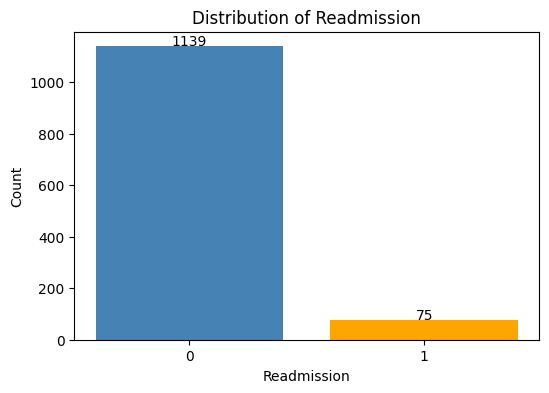

In [11]:
import matplotlib.pyplot as plt

# Target counts
target_counts = df["readmit"].value_counts().sort_index()

# Create color list
colors = ["steelblue", "orange"]


plt.figure(figsize=(6,4))

bars = plt.bar(
    target_counts.index.astype(str),
    target_counts.values,
    color=colors
)

plt.title("Distribution of Readmission")
plt.xlabel("Readmission")
plt.ylabel("Count")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha='center'
    )

plt.show()

| Class              | Count |      % |
| ------------------ | ----: | -----: |
| No Readmission (0) |  1139 | 93.82% |
| Readmission (1)    |    75 |  6.18% |

Accuracy alone is misleading because a naïve model predicting no readmission for all patients would achieve nearly 94% accuracy while failing to identify any patients requiring intervention



### Relationship between target vs explanaotry variables

<Figure size 600x400 with 0 Axes>

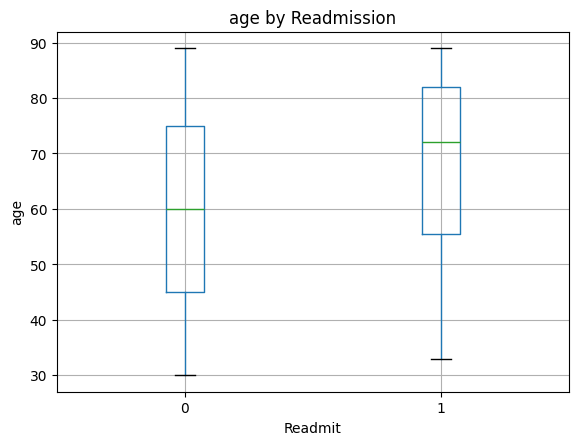

<Figure size 600x400 with 0 Axes>

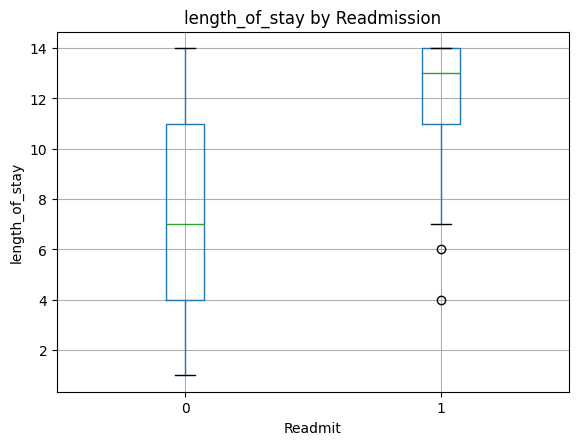

<Figure size 600x400 with 0 Axes>

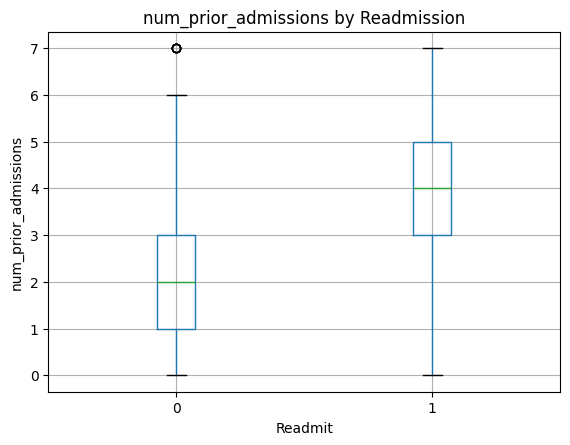

In [12]:
import matplotlib.pyplot as plt

features = [
    "age",
    "length_of_stay",
    "num_prior_admissions"
]

for col in features:
    plt.figure(figsize=(6,4))

    df.boxplot(column=col, by="readmit")

    plt.title(f"{col} by Readmission")
    plt.suptitle("")
    plt.xlabel("Readmit")
    plt.ylabel(col)

    plt.show()



* Patients who were readmitted tended to be older on average compared to patients who were not readmitted. This suggests age may be positively associated with the likelihood of hospital readmission.

* Length of stay appears to be one of the strongest predictors of readmission. Patients who were readmitted generally experienced substantially longer hospital stays, with a noticeably higher median length of stay compared to non-readmitted patients.

* Patients who were readmitted tended to have a higher number of prior admissions on average compared to those who were not readmitted. This suggests that a history of frequent hospital admissions may be associated with an increased likelihood of future readmission.

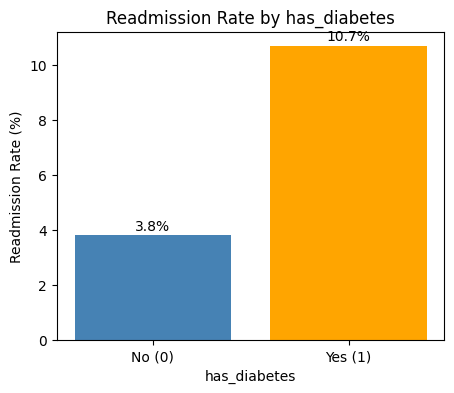


has_diabetes Readmission Rate:
has_diabetes
0     3.787879
1    10.663507
Name: readmit, dtype: float64


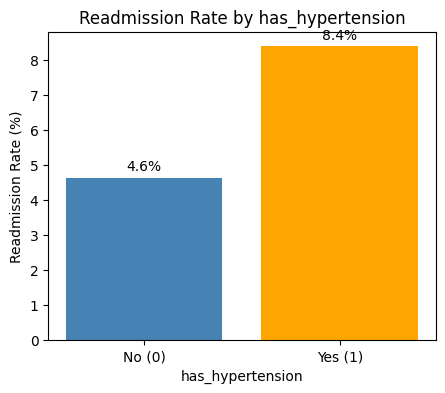


has_hypertension Readmission Rate:
has_hypertension
0    4.628331
1    8.383234
Name: readmit, dtype: float64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

categorical_vars = [
    "has_diabetes",
    "has_hypertension"
]

for col in categorical_vars:

    # Readmission rate only
    readmit_rate = (
        df.groupby(col)["readmit"]
        .mean() * 100
    )

    plt.figure(figsize=(5,4))

    bars = plt.bar(
        ["No (0)", "Yes (1)"],
        readmit_rate.values,
        color=["steelblue", "orange"]
    )

    plt.title(f"Readmission Rate by {col}")
    plt.ylabel("Readmission Rate (%)")
    plt.xlabel(col)

    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.2,
            f"{height:.1f}%",
            ha='center'
        )

    plt.show()

    print(f"\n{col} Readmission Rate:")
    print(readmit_rate)

Patients with diabetes demonstrated substantially higher readmission rates (10.7%) compared to non-diabetic patients (3.8%). Similarly, patients with hypertension exhibited higher readmission rates (8.4%) than those without hypertension (4.6%), suggesting both conditions may be associated with elevated readmission risk.

## Modeling

### Train/Test Split

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("readmit", axis=1)
y = df["readmit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,      # important for imbalance
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))

print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

Train shape: (971, 5)
Test shape: (243, 5)

Train target balance:
readmit
0    0.938208
1    0.061792
Name: proportion, dtype: float64

Test target balance:
readmit
0    0.938272
1    0.061728
Name: proportion, dtype: float64


### Standard Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data
X_test_scaled = scaler.transform(X_test)

### 1. Logistic Regresison

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

# Fit model
log_model.fit(X_train_scaled, y_train)

# Predictions
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# AUC
auc = roc_auc_score(y_test, log_probs)

print("AUC:", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_preds))

print("\nClassification Report:")
print(classification_report(y_test, log_preds))

AUC: 0.9585

Confusion Matrix:
[[197  31]
 [  1  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       228
           1       0.31      0.93      0.47        15

    accuracy                           0.87       243
   macro avg       0.65      0.90      0.70       243
weighted avg       0.95      0.87      0.90       243



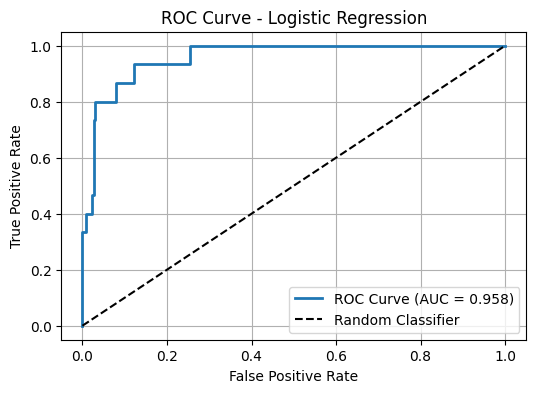

AUC: 0.9585


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, log_probs)

# AUC
auc = roc_auc_score(y_test, log_probs)

# Plot
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {auc:.3f})',
    linewidth=2
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)

plt.show()

print(f"AUC: {auc:.4f}")

Best Youden's J Threshold: 0.5634


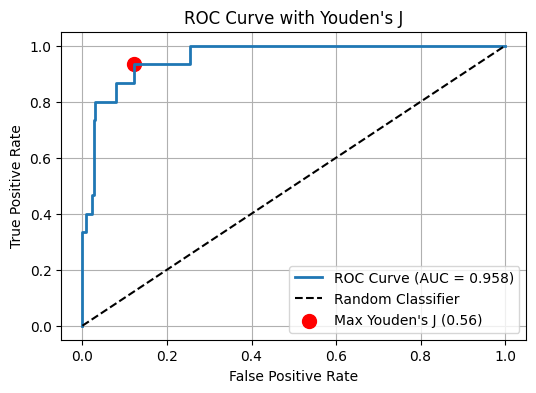

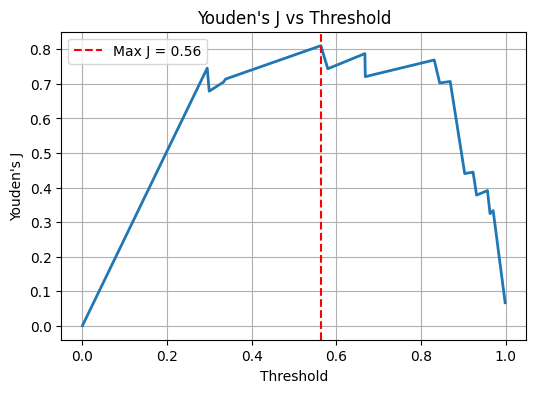

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    log_probs
)

# AUC
auc = roc_auc_score(
    y_test,
    log_probs
)

# -------------------------
# Youden's J
# -------------------------
youden_j = tpr - fpr

# Index of max J
max_j_idx = np.argmax(youden_j)

# Best threshold
best_threshold = thresholds[max_j_idx]

print(f"Best Youden's J Threshold: {best_threshold:.4f}")

# -------------------------
# ROC Curve
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {auc:.3f})',
    linewidth=2
)

# Random line
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

# Best Youden point
plt.scatter(
    fpr[max_j_idx],
    tpr[max_j_idx],
    color='red',
    s=100,
    label=f"Max Youden's J ({best_threshold:.2f})"
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve with Youden's J")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------
# Youden J vs Threshold
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    thresholds,
    youden_j,
    linewidth=2
)

plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    label=f'Max J = {best_threshold:.2f}'
)

plt.xlabel('Threshold')
plt.ylabel("Youden's J")
plt.title("Youden's J vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

### LR- Business loss functoin

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score

def find_best_business_threshold(
    y_true,
    y_prob,
    fp_cost=20000,
    fn_cost=150000,
    tp_cost=20000,
    threshold_grid=None
):
    if threshold_grid is None:
        threshold_grid = np.arange(0.00, 1.01, 0.01)

    results = []

    for threshold in threshold_grid:
        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        business_cost = (
            tp * tp_cost +
            fp * fp_cost +
            fn * fn_cost
        )

        results.append({
            "threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "F1": f1_score(y_true, y_pred),
            "business_cost": business_cost
        })

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[
        results_df["business_cost"].idxmin()
    ]

    return best_row, results_df

In [25]:
best_cost_row, cost_results = find_best_business_threshold(
    y_test,
    log_probs
)

best_cost_row

threshold             0.800000
TN                  220.000000
FP                    8.000000
FN                    3.000000
TP                   12.000000
F1                    0.685714
business_cost    850000.000000
Name: 80, dtype: float64

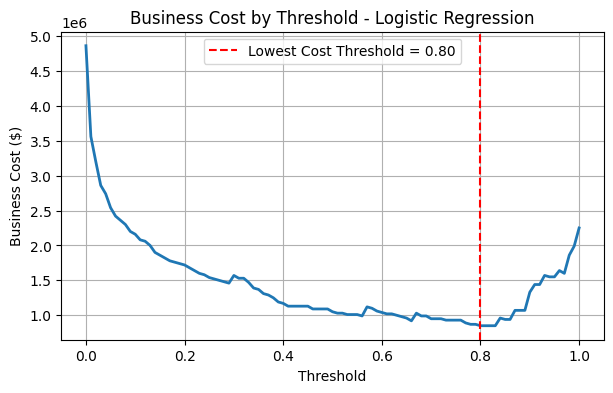

threshold             0.800000
TN                  220.000000
FP                    8.000000
FN                    3.000000
TP                   12.000000
F1                    0.685714
business_cost    850000.000000
Name: 80, dtype: float64


In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    cost_results["threshold"],
    cost_results["business_cost"],
    linewidth=2
)

plt.axvline(
    best_cost_row["threshold"],
    color="red",
    linestyle="--",
    label=f"Lowest Cost Threshold = {best_cost_row['threshold']:.2f}"
)

plt.title("Business Cost by Threshold - Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("Business Cost ($)")
plt.legend()
plt.grid(True)

plt.show()

print(best_cost_row)

Although the default classification threshold is 0.50, a business-cost optimization analysis identified 0.80 as the optimal threshold for minimizing hospital expenses. Lower thresholds resulted in excessive intervention costs due to unnecessary extended stays, while higher thresholds increased expensive readmissions caused by missed high-risk patients.

### Comparing between Youden's J threshold: 0.56 and Lowest business cost

In [31]:
from sklearn.metrics import confusion_matrix, f1_score
import pandas as pd

def evaluate_threshold(
    y_true,
    y_prob,
    threshold,
    fp_cost=20000,
    fn_cost=150000,
    tp_cost=20000
):

    # Predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    # Business cost
    business_cost = (
        tp * tp_cost +
        fp * fp_cost +
        fn * fn_cost
    )

    # Metrics table
    results = pd.DataFrame({
        "Metric": [
            "Threshold",
            "TN",
            "FP",
            "FN",
            "TP",
            "F1 Score",
            "Business Cost"
        ],
        "Value": [
            threshold,
            tn,
            fp,
            fn,
            tp,
            round(f1_score(y_true, y_pred), 4),
            f"${business_cost:,.0f}"
        ]
    })

    return results


# ----------------------------
# Evaluate both thresholds
# ----------------------------

youden_results = evaluate_threshold(
    y_test,
    log_probs,
    threshold=0.56
)

business_results = evaluate_threshold(
    y_test,
    log_probs,
    threshold=0.80
)

print("Youden's J Threshold (0.56)")
display(youden_results)

print("\nBusiness Optimal Threshold (0.80)")
display(business_results)

Youden's J Threshold (0.56)


,Metric,Value
0,Threshold,0.56
1,TN,200
2,FP,28
3,FN,1
4,TP,14
5,F1 Score,0.4912
6,Business Cost,"$990,000"



Business Optimal Threshold (0.80)


,Metric,Value
0,Threshold,0.8
1,TN,220
2,FP,8
3,FN,3
4,TP,12
5,F1 Score,0.6857
6,Business Cost,"$850,000"


In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_heatmap(
    y_true,
    y_prob,
    threshold,
    title="Confusion Matrix"
):

    # Convert probabilities to predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{title}\nThreshold = {threshold:.2f}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"],
        rotation=0
    )

    plt.show()

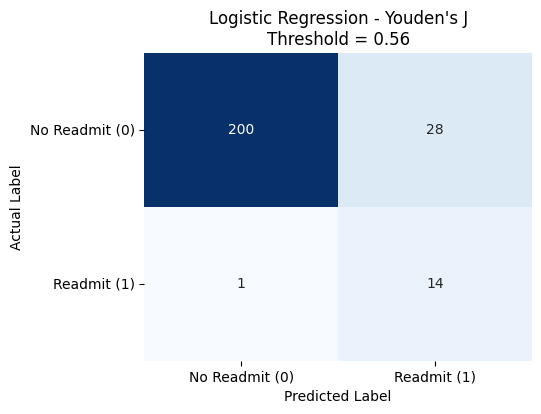

In [29]:
plot_confusion_heatmap(
    y_test,
    log_probs,
    threshold=0.56,
    title="Logistic Regression - Youden's J"
)

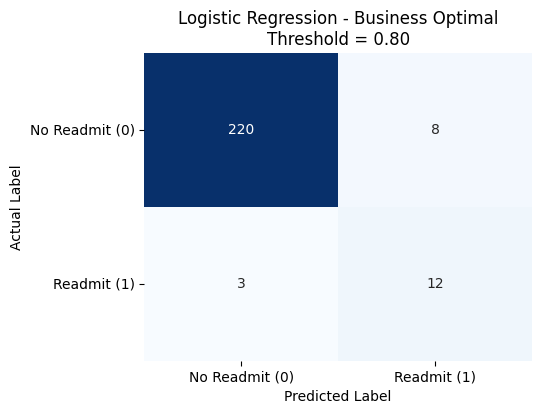

In [30]:
plot_confusion_heatmap(
    y_test,
    log_probs,
    threshold=0.80,
    title="Logistic Regression - Business Optimal"
)

| Metric        | Youden’s J (0.56) | Business Threshold (0.80) |
| ------------- | ----------------: | ------------------------: |
| TN            |               200 |                   **220** |
| FP            |                28 |                     **8** |
| FN            |             **1** |                         3 |
| TP            |                14 |                        12 |
| F1            |             0.491 |                 **0.686** |
| Business Cost |          $990,000 |              **$850,000** |


| Strategy           |         Cost | Savings vs No Model |
| ------------------ | -----------: | ------------------: |
| No model           |   $2,250,000 |                   — |
| Default 0.50       |   $1,050,000 |          $1,200,000 |
| Youden J           |     $990,000 |          $1,260,000 |
| Business threshold | **$850,000** |      **$1,400,000** |


While Youden’s J threshold (0.56) optimized statistical classification balance, the business-optimal threshold (0.80) reduced unnecessary interventions and lowered total hospital cost from $990,000 to $850,000, generating an estimated $140,000 savings on the test set.

### LR - Internal 5-fold CV

In [32]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd
import numpy as np

# -------------------------
# Data
# -------------------------
X = df.drop("readmit", axis=1)
y = df["readmit"]

# -------------------------
# CV Setup
# -------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold = 0.80

# Costs
FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

results = []

# -------------------------
# Cross Validation Loop
# -------------------------
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    # -------------------------
    # Scale within fold
    # -------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_val_scaled = scaler.transform(X_val_cv)

    # -------------------------
    # Model
    # -------------------------
    model = LogisticRegression(
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train_cv
    )

    # Probabilities
    probs = model.predict_proba(
        X_val_scaled
    )[:, 1]

    # Custom threshold
    preds = (probs >= threshold).astype(int)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val_cv,
        preds
    ).ravel()

    # Specificity
    specificity = tn / (tn + fp)

    # Business Cost
    business_cost = (
        tp * TP_COST +
        fp * FP_COST +
        fn * FN_COST
    )

    # Metrics
    results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val_cv, preds),
        "Recall": recall_score(y_val_cv, preds),
        "Precision": precision_score(y_val_cv, preds),
        "Specificity": specificity,
        "F1": f1_score(y_val_cv, preds),
        "AUC": roc_auc_score(y_val_cv, probs),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Business Cost": business_cost
    })

# -------------------------
# Results Table
# -------------------------
cv_results = pd.DataFrame(results)

display(cv_results)

# -------------------------
# Average Performance
# -------------------------
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Recall",
        "Precision",
        "Specificity",
        "F1",
        "AUC",
        "Business Cost"
    ],
    "Mean": [
        cv_results["Accuracy"].mean(),
        cv_results["Recall"].mean(),
        cv_results["Precision"].mean(),
        cv_results["Specificity"].mean(),
        cv_results["F1"].mean(),
        cv_results["AUC"].mean(),
        cv_results["Business Cost"].mean()
    ],
    "Std Dev": [
        cv_results["Accuracy"].std(),
        cv_results["Recall"].std(),
        cv_results["Precision"].std(),
        cv_results["Specificity"].std(),
        cv_results["F1"].std(),
        cv_results["AUC"].std(),
        cv_results["Business Cost"].std()
    ]
})

display(summary)

,Fold,Accuracy,Recall,Precision,Specificity,F1,AUC,TN,FP,FN,TP,Business Cost
0,1,0.934156,0.666667,0.476190,0.951754,0.555556,0.932310,217,11,5,10,1170000
1,2,0.905350,0.533333,0.333333,0.929825,0.410256,0.941813,212,16,7,8,1530000
2,3,0.954733,0.866667,0.590909,0.960526,0.702703,0.982456,219,9,2,13,740000
3,4,0.930041,0.800000,0.461538,0.938596,0.585366,0.929825,214,14,3,12,970000
4,5,0.933884,0.466667,0.466667,0.964758,0.466667,0.910720,219,8,8,7,1500000


,Metric,Mean,Std Dev
0,Accuracy,9.316328e-01,0.017595
1,Recall,6.666667e-01,0.169967
2,Precision,4.657276e-01,0.091278
3,Specificity,9.490919e-01,0.014702
4,F1,5.441094e-01,0.112804
5,AUC,9.394246e-01,0.026571
6,Business Cost,1.182000e+06,340102.925598


In [73]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score
)

# -------------------------
# Threshold grid
# -------------------------
threshold_grid = np.arange(
    0.00,
    1.01,
    0.01
)

# -------------------------
# Costs
# -------------------------
FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

# -------------------------
# CV setup
# -------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    # Split
    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    # -------------------------
    # Scale inside fold
    # -------------------------
    scaler = StandardScaler()

    X_train_scaled_cv = scaler.fit_transform(
        X_train_cv
    )

    X_val_scaled_cv = scaler.transform(
        X_val_cv
    )

    # -------------------------
    # Logistic Regression
    # -------------------------
    model = LogisticRegression(
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_scaled_cv,
        y_train_cv
    )

    probs = model.predict_proba(
        X_val_scaled_cv
    )[:, 1]

    threshold_results = []

    # -------------------------
    # Threshold search
    # -------------------------
    for threshold in threshold_grid:

        preds = (
            probs >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        business_cost = (
            tp * TP_COST +
            fp * FP_COST +
            fn * FN_COST
        )

        threshold_results.append({
            "threshold": threshold,
            "business_cost": business_cost,
            "f1": f1_score(
                y_val_cv,
                preds,
                zero_division=0
            )
        })

    threshold_df = pd.DataFrame(
        threshold_results
    )

    best_row = threshold_df.loc[
        threshold_df[
            "business_cost"
        ].idxmin()
    ]

    results.append({
        "Fold": fold,
        "Best Threshold": best_row["threshold"],
        "Lowest Cost": best_row["business_cost"],
        "F1": best_row["f1"]
    })

logistic_threshold_results = pd.DataFrame(
    results
)

display(logistic_threshold_results)

print(
    "Average Best Threshold:",
    round(
        logistic_threshold_results[
            "Best Threshold"
        ].mean(),
        3
    )
)

print(
    "Threshold Std Dev:",
    round(
        logistic_threshold_results[
            "Best Threshold"
        ].std(),
        3
    )
)

print(
    "Average Lowest Cost:",
    round(
        logistic_threshold_results[
            "Lowest Cost"
        ].mean(),
        0
    )
)

,Fold,Best Threshold,Lowest Cost,F1
0,1,0.45,1130000.0,0.437500
1,2,0.57,1010000.0,0.482759
2,3,0.79,630000.0,0.717949
3,4,0.65,890000.0,0.538462
4,5,0.71,1210000.0,0.526316


Average Best Threshold: 0.634
Threshold Std Dev: 0.131
Average Lowest Cost: 974000.0


In [75]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd
import numpy as np

# -------------------------
# Data
# -------------------------
X = df.drop("readmit", axis=1)
y = df["readmit"]

# -------------------------
# Thresholds to compare
# -------------------------
thresholds_to_test = [0.50, 0.56, 0.634, 0.80]

# Costs
FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

# -------------------------
# CV Setup
# -------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_results = []

# -------------------------
# Loop through thresholds
# -------------------------
for threshold in thresholds_to_test:

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        # -------------------------
        # Scale within fold
        # -------------------------
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_cv)
        X_val_scaled = scaler.transform(X_val_cv)

        # -------------------------
        # Logistic Regression
        # -------------------------
        model = LogisticRegression(
            class_weight="balanced",
            random_state=42
        )

        model.fit(
            X_train_scaled,
            y_train_cv
        )

        # Probabilities
        probs = model.predict_proba(
            X_val_scaled
        )[:, 1]

        # Apply threshold
        preds = (
            probs >= threshold
        ).astype(int)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        # Specificity
        specificity = tn / (tn + fp)

        # Business Cost
        business_cost = (
            tp * TP_COST +
            fp * FP_COST +
            fn * FN_COST
        )

        fold_results.append({
            "Accuracy": accuracy_score(y_val_cv, preds),
            "Recall": recall_score(y_val_cv, preds),
            "Precision": precision_score(y_val_cv, preds, zero_division=0),
            "Specificity": specificity,
            "F1": f1_score(y_val_cv, preds, zero_division=0),
            "AUC": roc_auc_score(y_val_cv, probs),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Business Cost": business_cost
        })

    # Convert folds to DF
    fold_df = pd.DataFrame(fold_results)

    # Mean summary
    all_results.append({
        "Threshold": threshold,
        "Accuracy": fold_df["Accuracy"].mean(),
        "Recall": fold_df["Recall"].mean(),
        "Precision": fold_df["Precision"].mean(),
        "Specificity": fold_df["Specificity"].mean(),
        "F1": fold_df["F1"].mean(),
        "AUC": fold_df["AUC"].mean(),
        "TN": fold_df["TN"].mean(),
        "FP": fold_df["FP"].mean(),
        "FN": fold_df["FN"].mean(),
        "TP": fold_df["TP"].mean(),
        "Business Cost": fold_df["Business Cost"].mean()
    })

# -------------------------
# Final comparison table
# -------------------------
threshold_summary = pd.DataFrame(all_results)

threshold_summary = threshold_summary.round(4)

display(threshold_summary)

,Threshold,Accuracy,Recall,Precision,Specificity,F1,AUC,TN,FP,FN,TP,Business Cost
0,0.500,0.8591,0.8800,0.2893,0.8578,0.4351,0.9394,195.4,32.4,1.8,13.2,1182000.0
1,0.560,0.8740,0.8667,0.3120,0.8745,0.4583,0.9394,199.2,28.6,2.0,13.0,1132000.0
2,0.634,0.9012,0.8133,0.3645,0.9069,0.5024,0.9394,206.6,21.2,2.8,12.2,1088000.0
3,0.800,0.9316,0.6667,0.4657,0.9491,0.5441,0.9394,216.2,11.6,5.0,10.0,1182000.0


Although threshold 0.80 produced the highest F1 score, it resulted in a higher business cost due to increased false negatives, which carry substantially larger financial penalties ($150,000 per missed readmission). Therefore, threshold 0.56 was selected as the preferred threshold because it minimized expected hospital cost while maintaining strong predictive performance.

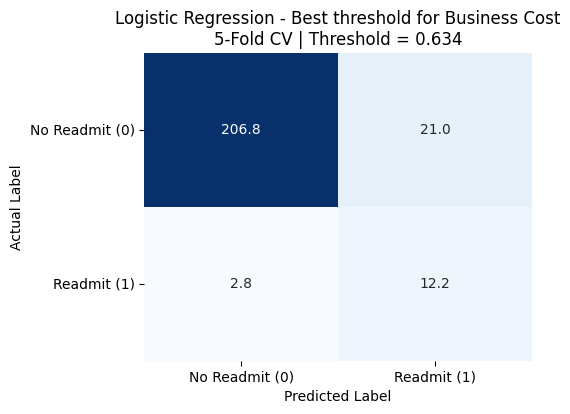

array([[206.8,  21. ],
       [  2.8,  12.2]])

In [76]:
cv_confusion_matrix_heatmap(
    model,
    X,
    y,
    threshold=0.634,
    title="Logistic Regression - Best threshold for Business Cost"
)

## 2. Random Forest
### Grid Search


In [38]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


# Base model
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Grid
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [9, 10, 11, 12],
    "min_samples_leaf": [4, 5, 6, 7],
    "min_samples_split": [2, 3, 4],
}

# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit
rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV AUC:")
print(round(rf_grid.best_score_, 4))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Best CV AUC:
0.9254


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -------------------------
# Random Forest Model
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Fit
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, rf_probs)

print("AUC:", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

AUC: 0.9553

Confusion Matrix:
[[218  10]
 [  7   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       228
           1       0.44      0.53      0.48        15

    accuracy                           0.93       243
   macro avg       0.71      0.74      0.72       243
weighted avg       0.94      0.93      0.93       243



### RF - ROC Curve

[0.         0.         0.         0.00438596 0.00438596 0.01315789
 0.01315789 0.02192982 0.02192982 0.04385965 0.04385965 0.07017544
 0.07017544 0.09649123 0.09649123 0.17982456 0.17982456 0.27631579
 0.28508772 0.31140351 0.32017544 0.40350877 0.4122807  0.53070175
 0.53947368 0.55263158 0.56578947 0.57017544 0.5877193  0.59210526
 0.60964912 0.61842105 0.62719298 0.64035088 0.64912281 0.65350877
 0.66666667 0.68421053 1.        ]
[0.         0.06666667 0.13333333 0.13333333 0.26666667 0.26666667
 0.46666667 0.46666667 0.53333333 0.53333333 0.66666667 0.66666667
 0.8        0.8        0.93333333 0.93333333 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
[       inf 0.96910916 0.95325879 0.8925142  0.84432615 0.81307477
 0.8059646  0.74221059 0.67768152 0.54378662 0.49119225 0.33818797
 0.32041232 0.25145036 0

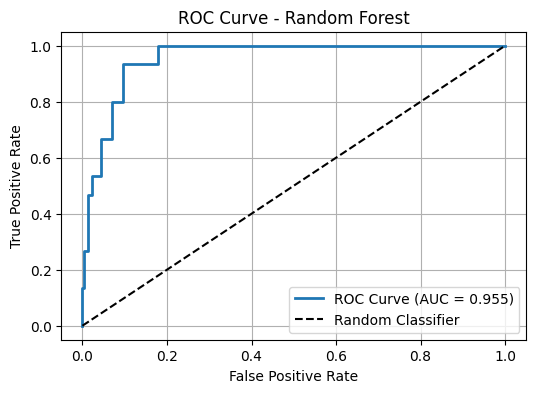

AUC: 0.9553


In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

print(fpr)
print(tpr)
print(thresholds)

auc = roc_auc_score(
    y_test,
    rf_probs
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()

print(f"AUC: {auc:.4f}")

### RF - Youden'J

In [41]:
import numpy as np

# Youden's J
youden_j = tpr - fpr

max_j_idx = np.argmax(youden_j)

rf_best_threshold = thresholds[max_j_idx]

print(
    f"Best Youden's J Threshold: {rf_best_threshold:.4f}"
)



Best Youden's J Threshold: 0.2111


Best Youden's J Threshold: 0.2111


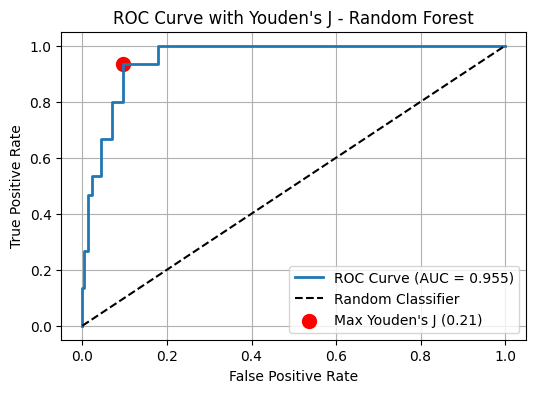

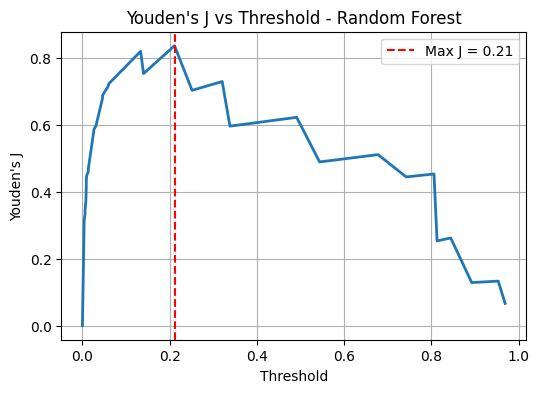

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# ROC values
# -------------------------
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

# AUC
auc = roc_auc_score(
    y_test,
    rf_probs
)

# -------------------------
# Youden's J
# -------------------------
youden_j = tpr - fpr

# Max J index
max_j_idx = np.argmax(youden_j)

# Best threshold
best_threshold = thresholds[max_j_idx]

print(f"Best Youden's J Threshold: {best_threshold:.4f}")

# -------------------------
# ROC Curve
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {auc:.3f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

# Best Youden point
plt.scatter(
    fpr[max_j_idx],
    tpr[max_j_idx],
    color='red',
    s=100,
    label=f"Max Youden's J ({best_threshold:.2f})"
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve with Youden's J - Random Forest")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------
# Youden's J vs Threshold
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    thresholds,
    youden_j,
    linewidth=2
)

plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    label=f'Max J = {best_threshold:.2f}'
)

plt.xlabel("Threshold")
plt.ylabel("Youden's J")
plt.title("Youden's J vs Threshold - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
rf_default = evaluate_threshold(
    y_test,
    rf_probs,
    threshold=0.50
)

rf_youden = evaluate_threshold(
    y_test,
    rf_probs,
    threshold=rf_best_threshold
)

print("Default Threshold (0.50)")
display(rf_default)

print("Youden's J Threshold")
display(rf_youden)

Default Threshold (0.50)


,Metric,Value
0,Threshold,0.5
1,TN,218
2,FP,10
3,FN,7
4,TP,8
5,F1 Score,0.4848
6,Business Cost,"$1,410,000"


Youden's J Threshold


,Metric,Value
0,Threshold,0.211126
1,TN,206
2,FP,22
3,FN,1
4,TP,14
5,F1 Score,0.549
6,Business Cost,"$870,000"


In [49]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best Random Forest model
best_rf = rf_grid.best_estimator_

print(best_rf)

def evaluate_rf_threshold(
    y_true,
    y_prob,
    threshold,
    model_name="Random Forest",
    fp_cost=20000,
    fn_cost=150000,
    tp_cost=20000
):

    # Predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    # Specificity
    specificity = tn / (tn + fp)

    # Business cost
    business_cost = (
        tp * tp_cost +
        fp * fp_cost +
        fn * fn_cost
    )

    # Metrics
    results = pd.DataFrame({
        "Metric": [
            "Threshold",
            "TN",
            "FP",
            "FN",
            "TP",
            "Accuracy",
            "Recall",
            "Precision",
            "Specificity",
            "F1 Score",
            "AUC",
            "Business Cost"
        ],
        "Value": [
            threshold,
            tn,
            fp,
            fn,
            tp,
            round(accuracy_score(y_true, y_pred), 4),
            round(recall_score(y_true, y_pred), 4),
            round(precision_score(y_true, y_pred), 4),
            round(specificity, 4),
            round(f1_score(y_true, y_pred), 4),
            round(roc_auc_score(y_true, y_prob), 4),
            f"${business_cost:,.0f}"
        ]
    })

    # ----------------------
    # Heatmap
    # ----------------------
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(
        f"{model_name}\nThreshold = {threshold:.2f}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"],
        rotation=0
    )

    plt.show()

    return results

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, n_jobs=-1, random_state=42)


In [80]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    f1_score
)

# -------------------------
# Threshold grid
# -------------------------
threshold_grid = np.arange(
    0.00,
    1.01,
    0.01
)

# -------------------------
# Costs
# -------------------------
FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

# -------------------------
# CV setup
# -------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    # -------------------------
    # Split
    # -------------------------
    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    # -------------------------
    # Train best RF
    # -------------------------
    best_rf.fit(
        X_train_cv,
        y_train_cv
    )

    probs = best_rf.predict_proba(
        X_val_cv
    )[:, 1]

    threshold_results = []

    # -------------------------
    # Threshold search
    # -------------------------
    for threshold in threshold_grid:

        preds = (
            probs >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        business_cost = (
            tp * TP_COST +
            fp * FP_COST +
            fn * FN_COST
        )

        threshold_results.append({
            "threshold": threshold,
            "business_cost": business_cost,
            "f1": f1_score(
                y_val_cv,
                preds,
                zero_division=0
            )
        })

    threshold_df = pd.DataFrame(
        threshold_results
    )

    best_row = threshold_df.loc[
        threshold_df[
            "business_cost"
        ].idxmin()
    ]

    results.append({
        "Fold": fold,
        "Best Threshold": best_row["threshold"],
        "Lowest Cost": best_row["business_cost"],
        "F1": best_row["f1"]
    })

rf_threshold_results = pd.DataFrame(
    results
)

display(rf_threshold_results)

print(
    "Average Best Threshold:",
    round(
        rf_threshold_results[
            "Best Threshold"
        ].mean(),
        3
    )
)

print(
    "Threshold Std Dev:",
    round(
        rf_threshold_results[
            "Best Threshold"
        ].std(),
        3
    )
)

print(
    "Average Lowest Cost:",
    round(
        rf_threshold_results[
            "Lowest Cost"
        ].mean(),
        0
    )
)

,Fold,Best Threshold,Lowest Cost,F1
0,1,0.31,1410000.0,0.416667
1,2,0.21,1090000.0,0.451613
2,3,0.45,690000.0,0.666667
3,4,0.27,830000.0,0.571429
4,5,0.26,1170000.0,0.470588


Average Best Threshold: 0.3
Threshold Std Dev: 0.091
Average Lowest Cost: 1038000.0


In [84]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd
import numpy as np


# Best Random Forest model
best_rf = rf_grid.best_estimator_

print(best_rf)
# Thresholds
thresholds_to_test = [0.50, 0.36, 0.21]

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

# Costs
FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

for threshold in thresholds_to_test:

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        # Train best RF
        best_rf.fit(
            X_train_cv,
            y_train_cv
        )

        # Probabilities
        probs = best_rf.predict_proba(
            X_val_cv
        )[:, 1]

        # Apply threshold
        preds = (
            probs >= threshold
        ).astype(int)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        # Specificity
        specificity = tn / (tn + fp)

        # Business Cost
        business_cost = (
            tp * TP_COST +
            fp * FP_COST +
            fn * FN_COST
        )

        fold_results.append({
            "Accuracy": accuracy_score(
                y_val_cv,
                preds
            ),
            "Recall": recall_score(
                y_val_cv,
                preds
            ),
            "Precision": precision_score(
                y_val_cv,
                preds,
                zero_division=0
            ),
            "Specificity": specificity,
            "F1": f1_score(
                y_val_cv,
                preds,
                zero_division=0
            ),
            "AUC": roc_auc_score(
                y_val_cv,
                probs
            ),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Business Cost": business_cost
        })

    fold_df = pd.DataFrame(
        fold_results
    )

    results.append({
        "Threshold": threshold,
        "Accuracy": fold_df["Accuracy"].mean(),
        "Recall": fold_df["Recall"].mean(),
        "Precision": fold_df["Precision"].mean(),
        "Specificity": fold_df["Specificity"].mean(),
        "F1": fold_df["F1"].mean(),
        "AUC": fold_df["AUC"].mean(),
        "TN": fold_df["TN"].mean(),
        "FP": fold_df["FP"].mean(),
        "FN": fold_df["FN"].mean(),
        "TP": fold_df["TP"].mean(),
        "Business Cost": fold_df["Business Cost"].mean()
    })

rf_threshold_summary = pd.DataFrame(
    results
).round(4)

display(rf_threshold_summary)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, n_jobs=-1, random_state=42)


,Threshold,Accuracy,Recall,Precision,Specificity,F1,AUC,TN,FP,FN,TP,Business Cost
0,0.50,0.9316,0.60,0.4725,0.9535,0.5207,0.9308,217.2,10.6,6.0,9.0,1292000.0
1,0.36,0.9061,0.76,0.3787,0.9157,0.5011,0.9308,208.6,19.2,3.6,11.4,1152000.0
2,0.21,0.8608,0.88,0.2922,0.8595,0.4385,0.9308,195.8,32.0,1.8,13.2,1174000.0


In [79]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

def cv_confusion_matrix_heatmap(
    model,
    X,
    y,
    threshold,
    title="CV Confusion Matrix"
):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    confusion_matrices = []

    for train_idx, val_idx in cv.split(X, y):

        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        # Fit model
        model.fit(
            X_train_cv,
            y_train_cv
        )

        # Probabilities
        probs = model.predict_proba(
            X_val_cv
        )[:, 1]

        # Threshold
        preds = (
            probs >= threshold
        ).astype(int)

        # Confusion matrix
        cm = confusion_matrix(
            y_val_cv,
            preds
        )

        confusion_matrices.append(cm)

    # Average confusion matrix
    avg_cm = np.mean(
        confusion_matrices,
        axis=0
    )

    # Heatmap
    plt.figure(figsize=(5,4))

    sns.heatmap(
        avg_cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False
    )

    plt.title(
        f"{title}\n5-Fold CV | Threshold = {threshold}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["No Readmit (0)", "Readmit (1)"],
        rotation=0
    )

    plt.show()

    return avg_cm

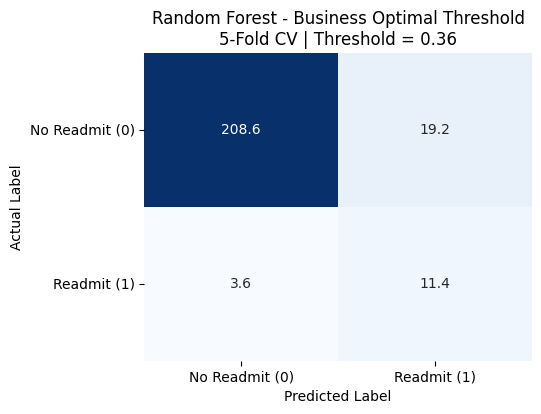

array([[208.6,  19.2],
       [  3.6,  11.4]])

In [86]:
# threshold = 0.50
cv_confusion_matrix_heatmap(
    best_rf,
    X,
    y,
    threshold=0.36,
    title="Random Forest - Business Optimal Threshold"
)

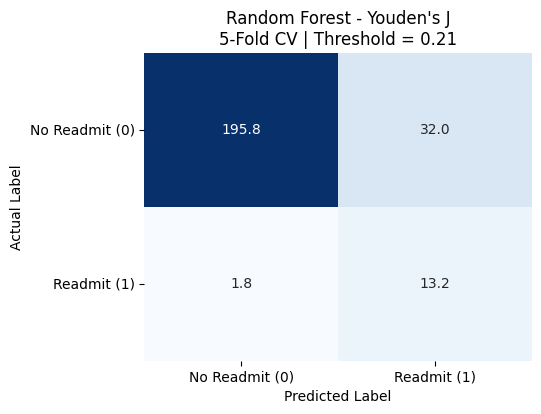

array([[195.8,  32. ],
       [  1.8,  13.2]])

In [53]:
cv_confusion_matrix_heatmap(
    best_rf,
    X,
    y,
    threshold=0.21,
    title="Random Forest - Youden's J"
)

## 3. Neural Network

In [54]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-macosx_10_13_universal2.whl.metadata (8.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl (223.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 29.9 MB/s  0:00:00
Using cached ml_dtypes-0.5.4-cp312-cp312-macosx_10_13_universal2.whl (676 kB)
Using cached absl_py-2.4.0-py3-none-any.whl (1

In [55]:
!pip install keras


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [57]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Load Packages

In [58]:
# first neural network with keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import keras.layers as layers
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from numpy import loadtxt

In [60]:
#print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#sess = tf.Session(config=tf.ConfigProto(log_device_placement=True))
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 17806798939510827621
xla_global_id: -1
]


In [63]:
!pip install scikeras


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Dropout
from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# Features / target
X = df.drop("readmit", axis=1)
y = df["readmit"]

def build_clf(learning_rate=0.001, hidden_units=32):
    model = Sequential([
        InputLayer(input_shape=(5,)),
        Dense(hidden_units, activation="relu"),
        Dense(hidden_units, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[]
    )

    return model

nn = KerasClassifier(
    model=build_clf,
    verbose=0,
    random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", nn)
])

params = {
    "nn__batch_size": [32, 64],
    "nn__epochs": [50, 100, 200],
    "nn__model__learning_rate": [0.01, 0.001],
    "nn__model__hidden_units": [16, 32, 64]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    cv=cv,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)

gs.fit(X, y)

results = pd.DataFrame(gs.cv_results_)[[
    "param_nn__batch_size",
    "param_nn__epochs",
    "param_nn__model__learning_rate",
    "param_nn__model__hidden_units",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

display(results)

print("Best Params:")
print(gs.best_params_)

print("Best CV F1:")
print(gs.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/C

,param_nn__batch_size,param_nn__epochs,param_nn__model__learning_rate,param_nn__model__hidden_units,mean_test_score,rank_test_score
15,32,200,0.001,32,0.475155,1
18,64,50,0.010,16,0.472685,2
13,32,200,0.001,16,0.466927,3
24,64,100,0.010,16,0.462521,4
12,32,200,0.010,16,0.461074,5
23,64,50,0.001,64,0.458383,6
22,64,50,0.010,64,0.455624,7
8,32,100,0.010,32,0.450478,8
6,32,100,0.010,16,0.447827,9
29,64,100,0.001,64,0.445897,10


Best Params:
{'nn__batch_size': 32, 'nn__epochs': 200, 'nn__model__hidden_units': 32, 'nn__model__learning_rate': 0.001}
Best CV F1:
0.4751547303271441


In [65]:
best_nn = gs.best_estimator_

nn_probs = best_nn.predict_proba(X_test)[:, 1]

## NN - ROC AUC

Neural Network AUC: 0.9927
Best Youden's J Threshold: 0.2002


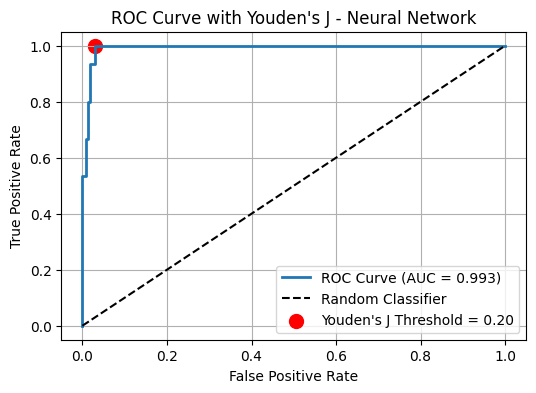

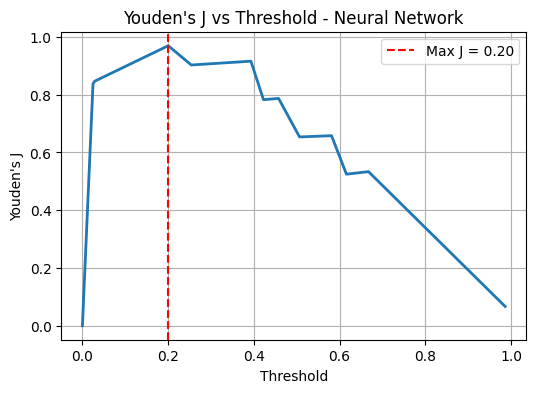

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Predicted probabilities
# -------------------------
nn_probs = best_nn.predict_proba(X_test)[:, 1]

# -------------------------
# ROC + AUC
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, nn_probs)
auc = roc_auc_score(y_test, nn_probs)

# -------------------------
# Youden's J
# -------------------------
youden_j = tpr - fpr
max_j_idx = np.argmax(youden_j)
nn_youden_threshold = thresholds[max_j_idx]

print(f"Neural Network AUC: {auc:.4f}")
print(f"Best Youden's J Threshold: {nn_youden_threshold:.4f}")

# -------------------------
# ROC Curve with Youden's J
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.scatter(
    fpr[max_j_idx],
    tpr[max_j_idx],
    color="red",
    s=100,
    label=f"Youden's J Threshold = {nn_youden_threshold:.2f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Youden's J - Neural Network")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Youden's J vs Threshold
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(
    thresholds,
    youden_j,
    linewidth=2
)

plt.axvline(
    nn_youden_threshold,
    color="red",
    linestyle="--",
    label=f"Max J = {nn_youden_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Youden's J")
plt.title("Youden's J vs Threshold - Neural Network")
plt.legend()
plt.grid(True)
plt.show()

### NN - Internal 5-fold

In [87]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

import numpy as np
import pandas as pd

thresholds_to_test = [0.50, 0.20, 0.108]

FP_COST = 20000
FN_COST = 150000
TP_COST = 20000

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train_scaled_cv = scaler.fit_transform(X_train_cv)
    X_val_scaled_cv = scaler.transform(X_val_cv)

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = Sequential([
        InputLayer(input_shape=(5,)),
        Dense(32, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    )

    model.fit(
        X_train_scaled_cv,
        y_train_cv,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    probs = model.predict(
        X_val_scaled_cv,
        verbose=0
    ).flatten()

    auc = roc_auc_score(y_val_cv, probs)

    for threshold in thresholds_to_test:

        preds = (probs >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        specificity = tn / (tn + fp)

        business_cost = (
            tp * TP_COST +
            fp * FP_COST +
            fn * FN_COST
        )

        all_results.append({
            "Fold": fold,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_val_cv, preds),
            "Recall": recall_score(y_val_cv, preds),
            "Precision": precision_score(y_val_cv, preds, zero_division=0),
            "Specificity": specificity,
            "F1": f1_score(y_val_cv, preds, zero_division=0),
            "AUC": auc,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Business Cost": business_cost
        })

cv_results = pd.DataFrame(all_results)

nn_threshold_summary = (
    cv_results
    .groupby("Threshold")
    .mean(numeric_only=True)
    .drop(columns="Fold")
    .reset_index()
    .round(4)
)

display(nn_threshold_summary)

/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/C

,Threshold,Accuracy,Recall,Precision,Specificity,F1,AUC,TN,FP,FN,TP,Business Cost
0,0.108,0.9094,0.6933,0.3736,0.9236,0.4844,0.9074,210.4,17.4,4.6,10.4,1246000.0
1,0.200,0.9218,0.5867,0.4095,0.9438,0.4810,0.9074,215.0,12.8,6.2,8.8,1362000.0
2,0.500,0.9432,0.4267,0.6008,0.9772,0.4895,0.9074,222.6,5.2,8.6,6.4,1522000.0


In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_cv_confusion_heatmaps_from_results(
    cv_results,
    thresholds_to_test,
    model_name="Neural Network"
):
    for threshold in thresholds_to_test:

        # Get average TN, FP, FN, TP for this threshold
        row = (
            cv_results[cv_results["Threshold"] == threshold]
            [["TN", "FP", "FN", "TP"]]
            .mean()
        )

        avg_cm = np.array([
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]]
        ])

        # Round for presentation
        avg_cm_rounded = np.round(avg_cm)

        plt.figure(figsize=(5,4))

        sns.heatmap(
            avg_cm_rounded,
            annot=True,
            fmt=".0f",
            cmap="Blues",
            cbar=False
        )

        plt.title(
            f"{model_name}\n5-Fold CV Average Confusion Matrix\nThreshold = {threshold}"
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")

        plt.xticks(
            [0.5, 1.5],
            ["No Readmit (0)", "Readmit (1)"]
        )

        plt.yticks(
            [0.5, 1.5],
            ["No Readmit (0)", "Readmit (1)"],
            rotation=0
        )

        plt.show()

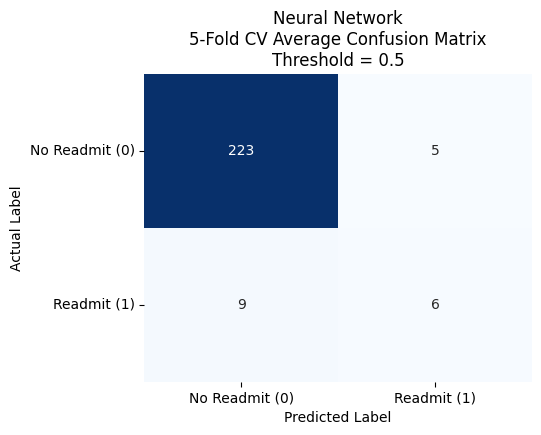

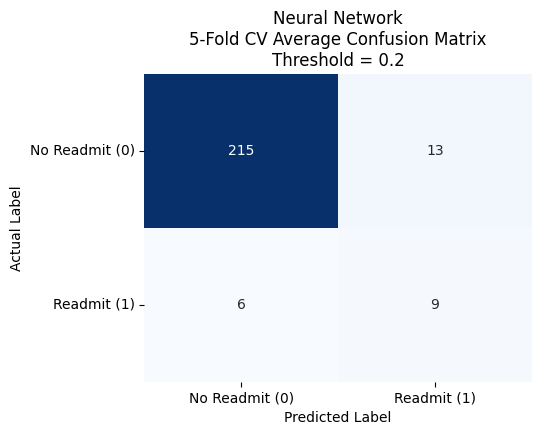

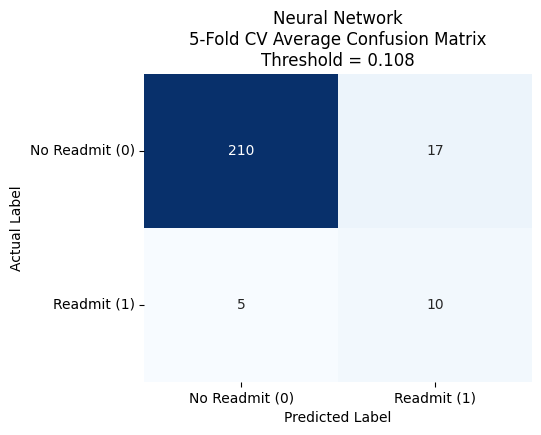

In [90]:
plot_cv_confusion_heatmaps_from_results(
    cv_results=cv_results,
    thresholds_to_test=[0.50, 0.20, 0.108],
    model_name="Neural Network"
)

In [69]:
import numpy as np
import pandas as pd

threshold_grid = np.arange(0.00, 1.01, 0.01)

results = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    # Scale
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_val_scaled = scaler.transform(X_val_cv)

    # Model
    tf.keras.backend.clear_session()

    model = Sequential([
        tf.keras.layers.InputLayer(input_shape=(5,)),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        )
    )

    model.fit(
        X_train_scaled,
        y_train_cv,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    probs = model.predict(
        X_val_scaled,
        verbose=0
    ).flatten()

    threshold_results = []

    for threshold in threshold_grid:

        preds = (
            probs >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val_cv,
            preds
        ).ravel()

        business_cost = (
            tp * 20000 +
            fp * 20000 +
            fn * 150000
        )

        threshold_results.append({
            "threshold": threshold,
            "business_cost": business_cost,
            "f1": f1_score(
                y_val_cv,
                preds,
                zero_division=0
            )
        })

    threshold_df = pd.DataFrame(
        threshold_results
    )

    best_row = threshold_df.loc[
        threshold_df["business_cost"].idxmin()
    ]

    results.append({
        "Fold": fold,
        "Best Threshold": best_row["threshold"],
        "Lowest Cost": best_row["business_cost"],
        "F1": best_row["f1"]
    })

cv_threshold_results = pd.DataFrame(results)

display(cv_threshold_results)

print(
    "Average Best Threshold:",
    round(
        cv_threshold_results[
            "Best Threshold"
        ].mean(),
        3
    )
)

print(
    "Average Lowest Cost:",
    round(
        cv_threshold_results[
            "Lowest Cost"
        ].mean(),
        0
    )
)

/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/Capstone-agentic/msds-capstone/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/Users/hayoungcheon/Documents/SMU/Capstone/C

,Fold,Best Threshold,Lowest Cost,F1
0,1,0.11,1180000.0,0.500000
1,2,0.06,1300000.0,0.440000
2,3,0.04,800000.0,0.545455
3,4,0.15,990000.0,0.571429
4,5,0.18,1220000.0,0.580645


Average Best Threshold: 0.108
Average Lowest Cost: 1098000.0


# Model Comparison

## Cost Optimization

| Model                  | Avg Threshold | Threshold SD | Avg Lowest Cost |
| ---------------------- | ------------: | -----------: | --------------: |
| 🥇 Logistic Regression |     **0.634** |        0.131 |       **$974K** |
| 🥈 Random Forest       |         0.300 |    **0.091** |         $1.038M |
| 🥉 Neural Network      |         0.108 |       ~0.058 |         $1.098M |


## Metrics Comparison
| Model                   | Avg Optimal Threshold | F1 Score |      AUC | Avg Lowest Business Cost | Recommendation    |
| ----------------------- | --------------------: | -------: | -------: | -----------------------: | ----------------- |
| **Logistic Regression** |             **0.634** | **0.54** | **0.94** |             **$974,000** | ✅ **Recommended** |
| Random Forest           |                 0.300 |     0.51 |     0.93 |               $1,038,000 | Good alternative  |
| Neural Network          |                 0.108 |     0.48 |     0.90 |               $1,098,000 | Not preferred     |


#### Key Takeaways
Logistic Regression achieved the lowest expected hospital cost ($974K) and strongest generalization performance (AUC ≈ 0.94).
Random Forest showed competitive performance but resulted in approximately $64K higher expected cost.
Neural Network achieved reasonable predictive performance but had the highest expected business cost and lower generalization in cross-validation.

#### Why Logistic Regression Won

✅ Lowest expected business loss.   
✅ Strong predictive performance (AUC ≈ 0.94).   
✅ Easier to explain to clinicians and executives.    
✅ Easier deployment and monitoring in hospital settings.    